# Class 08: Polynomial Regression & Regularization

---
## Generate Data

First, let's generate the curved data we'll use throughout this notebook.

In [1]:
import numpy as np
np.random.seed(42)

# Generate curved data: f(x) = sin(πx) + noise
X = np.linspace(0, 1, 30).reshape(-1, 1)
y = np.sin(np.pi * X).ravel() + np.random.normal(0, 0.1, 30)

print(f"Generated {len(X)} data points")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Generated 30 data points
X shape: (30, 1)
y shape: (30,)


---
## Linear Regression Fails on Curved Data

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred_linear = model_linear.predict(X)

print(f"R² = {r2_score(y, y_pred_linear):.3f}")

R² = 0.010


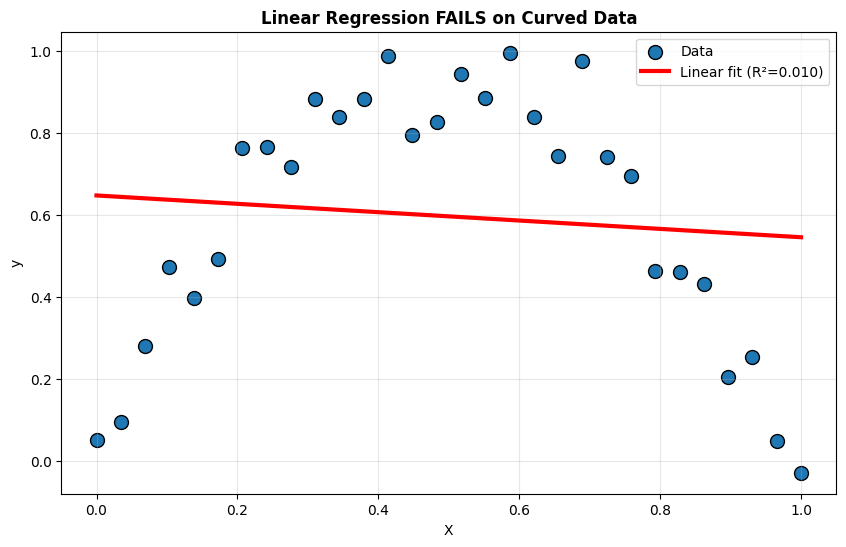

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=100, edgecolors='black', label='Data')
plt.plot(X, y_pred_linear, 'r-', linewidth=3, label=f'Linear fit (R²={r2_score(y, y_pred_linear):.3f})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression FAILS on Curved Data', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Polynomial Regression

**Idea:** Transform X → [X, X², X³] then apply linear regression

Model: y = w₀ + w₁·X + w₂·X² + w₃·X³

In [4]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)


LinearRegression()

---
## Overfitting Problem

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

Train: 21 samples
Test: 9 samples


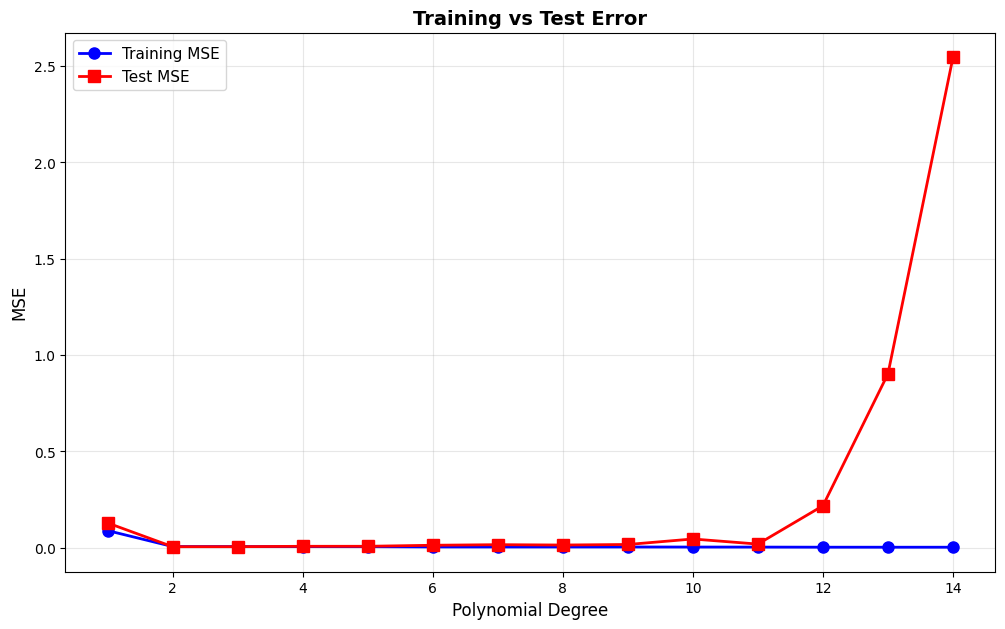

In [6]:
# Test degrees 1 to 14
degrees_test = range(1, 15)
train_errors = []
test_errors = []

for degree in degrees_test:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test_poly)))

# Plot
plt.figure(figsize=(12, 7))
plt.plot(degrees_test, train_errors, 'bo-', linewidth=2, markersize=8, label='Training MSE')
plt.plot(degrees_test, test_errors, 'rs-', linewidth=2, markersize=8, label='Test MSE')
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Training vs Test Error', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### Coefficient Explosion

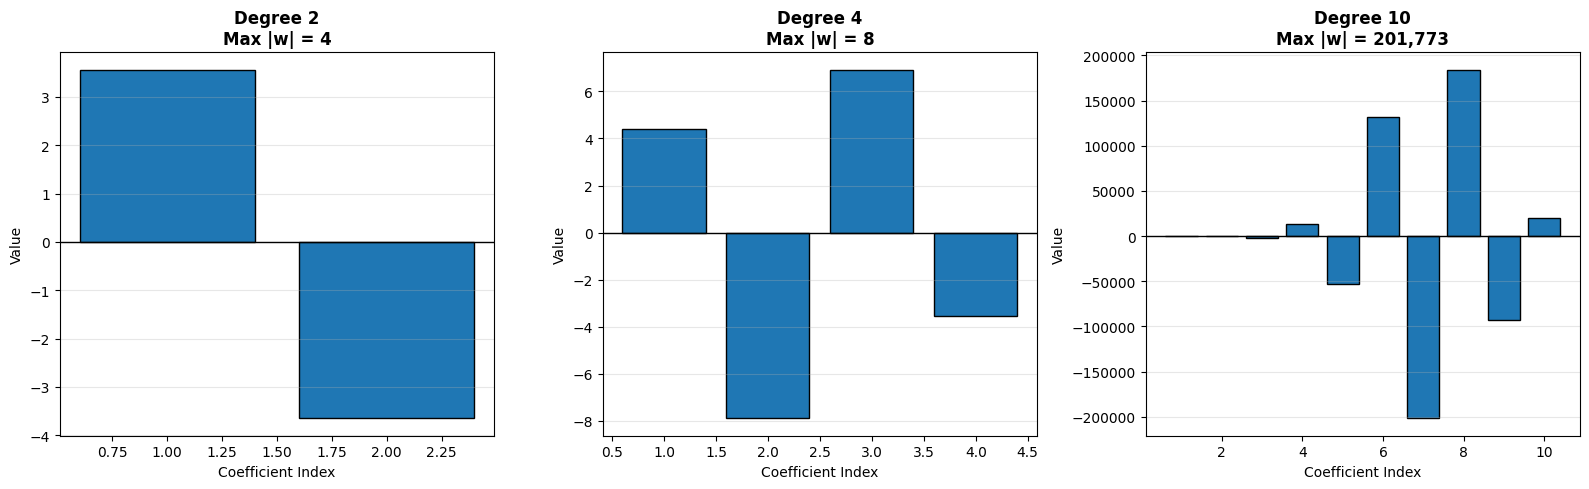

Degree 10: Coefficients EXPLODE to thousands/millions!
Large coefficients → Sharp wiggles → Overfitting


In [7]:
# Show coefficient growth
degrees_coef = [2, 4, 10]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, degree in enumerate(degrees_coef):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    coeffs = model.coef_[1:]  # Skip intercept
    axes[i].bar(range(1, len(coeffs)+1), coeffs, edgecolor='black')
    axes[i].set_title(f'Degree {degree}\nMax |w| = {np.max(np.abs(coeffs)):,.0f}', fontweight='bold')
    axes[i].set_xlabel('Coefficient Index')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

print("Degree 10: Coefficients EXPLODE to thousands/millions!")
print("Large coefficients → Sharp wiggles → Overfitting")

---
## Regularization

**Ridge (L2):** Loss = Bsae_Loss + α × Σwᵢ²  
**Lasso (L1):** Loss = Bsae_Loss + α × Σ|wᵢ|

In [8]:
from sklearn.linear_model import Ridge

degree = 10
alpha = 0.01

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# No regularization
model_no_reg = LinearRegression()
model_no_reg.fit(X_train_poly, y_train)

# Ridge
model_ridge = Ridge(alpha=alpha)
model_ridge.fit(X_train_poly, y_train)

# Evaluate
test_r2_no_reg = r2_score(y_test, model_no_reg.predict(X_test_poly))
test_r2_ridge = r2_score(y_test, model_ridge.predict(X_test_poly))

print(f"Degree {degree}:")
print(f"Without regularization: R² = {test_r2_no_reg:.3f}")
print(f"With Ridge (α={alpha}):  R² = {test_r2_ridge:.3f}")

Degree 10:
Without regularization: R² = 0.577
With Ridge (α=0.01):  R² = 0.922


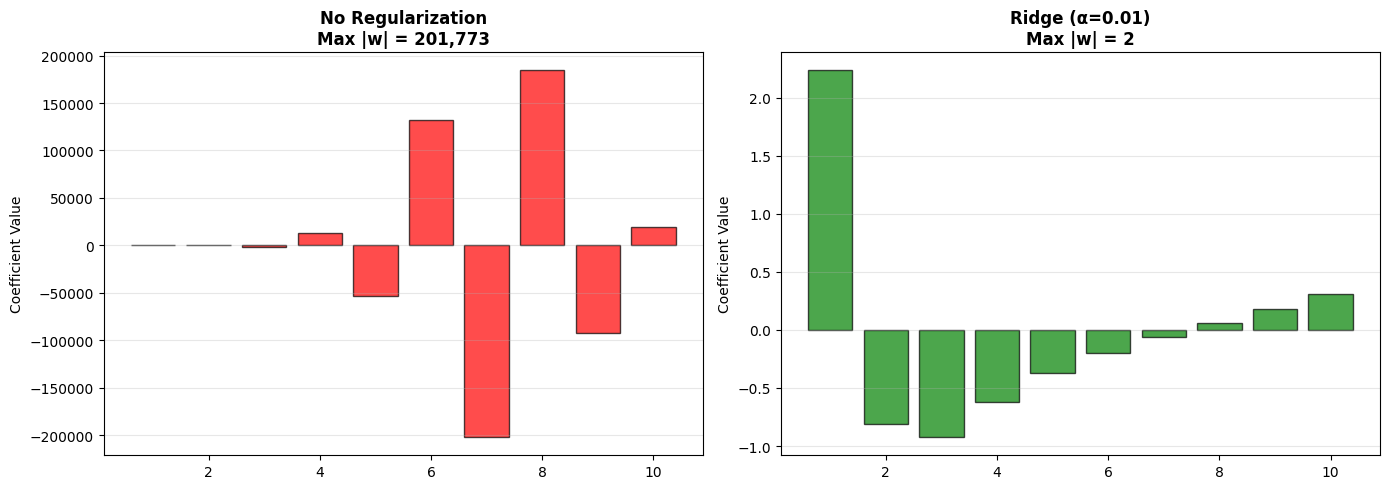

Ridge keeps coefficients SMALL → Better generalization


In [9]:
# Compare coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

coeffs_no_reg = model_no_reg.coef_[1:]
coeffs_ridge = model_ridge.coef_[1:]

ax1.bar(range(1, len(coeffs_no_reg)+1), coeffs_no_reg, edgecolor='black', color='red', alpha=0.7)
ax1.set_title(f'No Regularization\nMax |w| = {np.max(np.abs(coeffs_no_reg)):,.0f}', fontweight='bold')
ax1.set_ylabel('Coefficient Value')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(range(1, len(coeffs_ridge)+1), coeffs_ridge, edgecolor='black', color='green', alpha=0.7)
ax2.set_title(f'Ridge (α={alpha})\nMax |w| = {np.max(np.abs(coeffs_ridge)):,.0f}', fontweight='bold')
ax2.set_ylabel('Coefficient Value')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Ridge keeps coefficients SMALL → Better generalization")

### Ridge vs Lasso

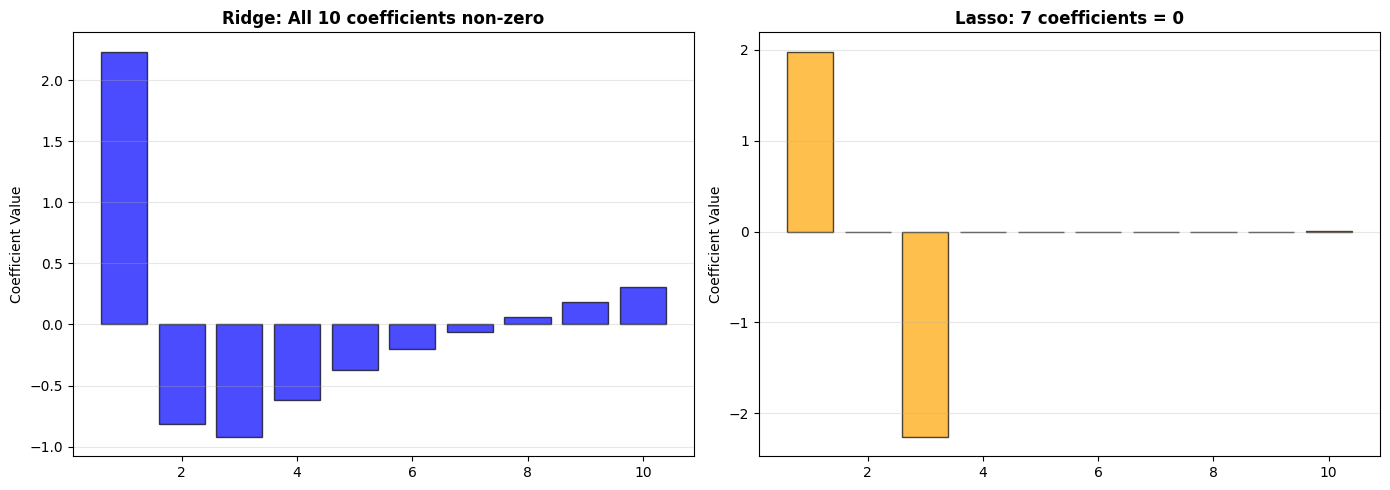

Ridge: Shrinks all coefficients
Lasso: Sets 7 coefficients to EXACTLY zero (feature selection)


In [10]:
# Lasso regularization
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.001)
model_lasso.fit(X_train_poly, y_train)

coeffs_lasso = model_lasso.coef_[1:]
zero_count = np.sum(np.abs(coeffs_lasso) < 0.0001)

# Compare
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(coeffs_ridge)+1), coeffs_ridge, edgecolor='black', color='blue', alpha=0.7)
ax1.set_title(f'Ridge: All {len(coeffs_ridge)} coefficients non-zero', fontweight='bold')
ax1.set_ylabel('Coefficient Value')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(range(1, len(coeffs_lasso)+1), coeffs_lasso, edgecolor='black', color='orange', alpha=0.7)
ax2.set_title(f'Lasso: {zero_count} coefficients = 0', fontweight='bold')
ax2.set_ylabel('Coefficient Value')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Ridge: Shrinks all coefficients")
print(f"Lasso: Sets {zero_count} coefficients to EXACTLY zero (feature selection)")